<a href="https://www.kaggle.com/code/jresona/notebook1b01198afb?scriptVersionId=354960575" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/anjalibhegam/multimodal-sports-injury-dataset/README.md
/kaggle/input/datasets/anjalibhegam/multimodal-sports-injury-dataset/multimodal_sports_injury_dataset.csv


In [2]:
import glob, time, os
import numpy as np
import pandas as pd

csv_path = glob.glob("/kaggle/input/**/*.csv", recursive=True)[0]
raw = pd.read_csv(csv_path)
print("Loaded:", csv_path)
print("Rows, Columns:", raw.shape)

Loaded: /kaggle/input/datasets/anjalibhegam/multimodal-sports-injury-dataset/multimodal_sports_injury_dataset.csv
Rows, Columns: (15420, 29)


In [3]:
keep_cols = ["athlete_id", "session_id",
             "training_duration", "training_intensity", "training_load",
             "heart_rate", "sleep_quality", "recovery_score", "stress_level",
             "fatigue_index"]
df = raw[keep_cols].copy()
print(df.shape)
df.head()

(15420, 10)


,athlete_id,session_id,training_duration,training_intensity,training_load,heart_rate,sleep_quality,recovery_score,stress_level,fatigue_index
0,1,1,79.106564,5.678475,548.417962,NaN,5.466370,77.899691,0.375825,45.028687
1,1,2,116.954654,NaN,538.043815,40.000000,6.899090,74.845323,0.279165,42.254717
2,1,3,96.354742,6.643242,647.784339,76.174609,9.574152,83.538316,0.334061,61.870056
3,1,4,97.619130,6.194427,336.553431,100.543724,7.614297,79.966618,0.218766,50.268845
4,1,5,83.155527,5.835804,496.076352,78.001235,5.631979,56.945979,0.484086,29.233575


In [4]:
print("=== MISSING VALUES ===")
print(df.isnull().sum())
print("\nFully duplicated rows:", df.duplicated().sum())
print("Repeated athlete+session pairs:", df.duplicated(subset=["athlete_id", "session_id"]).sum())
print("\n=== VALUE RANGES (outliers are NOT deleted) ===")
print(df.describe().T[["min", "mean", "max"]].round(2))

=== MISSING VALUES ===
athlete_id              0
session_id              0
training_duration       0
training_intensity    632
training_load           0
heart_rate            354
sleep_quality         493
recovery_score          0
stress_level            0
fatigue_index           0
dtype: int64

Fully duplicated rows: 0
Repeated athlete+session pairs: 0

=== VALUE RANGES (outliers are NOT deleted) ===
                       min    mean      max
athlete_id            1.00   78.55   156.00
session_id            1.00   49.93   101.00
training_duration    30.00   87.79   180.00
training_intensity    2.00    6.40    10.00
training_load       150.00  670.53  2632.64
heart_rate           40.00   72.69   159.27
sleep_quality         1.16    5.82    10.00
recovery_score        8.90   55.20    98.00
stress_level          0.10    0.42     0.95
fatigue_index        15.00   59.70   270.19


In [5]:
df = df.sort_values(["athlete_id", "session_id"]).reset_index(drop=True)
df["session_number"] = df.groupby("athlete_id").cumcount() + 1
print(df.groupby("athlete_id")["session_number"].max().describe().round(1))

count    156.0
mean      98.8
std        0.9
min       98.0
25%       98.0
50%       99.0
75%       99.0
max      101.0
Name: session_number, dtype: float64


In [6]:
g = df.groupby("athlete_id")

for w in [7, 14]:
    # shift(1) first, so only EARLIER sessions are used, never today's
    df[f"load_sum_{w}"] = g["training_load"].transform(
        lambda s: s.shift(1).rolling(w, min_periods=w).sum())
    df[f"load_mean_{w}"] = g["training_load"].transform(
        lambda s: s.shift(1).rolling(w, min_periods=w).mean())
    df[f"load_minus_mean_{w}"] = df["training_load"] - df[f"load_mean_{w}"]   # today vs history
    df[f"load_ratio_{w}"] = df["training_load"] / df[f"load_mean_{w}"]        # today vs history

for col in ["training_intensity", "heart_rate", "sleep_quality",
            "recovery_score", "stress_level"]:
    for w in [7, 14]:
        df[f"{col}_mean_{w}"] = g[col].transform(
            lambda s: s.shift(1).rolling(w, min_periods=3).mean())

df = df.replace([np.inf, -np.inf], np.nan)
print("Total columns now:", df.shape[1])

Total columns now: 29


In [7]:
a = df[df["athlete_id"] == df["athlete_id"].iloc[0]].reset_index(drop=True)
row15 = a[a["session_number"] == 15].iloc[0]

manual_sum7  = a[(a.session_number >= 8) & (a.session_number <= 14)]["training_load"].sum()
manual_sum14 = a[(a.session_number >= 1) & (a.session_number <= 14)]["training_load"].sum()

assert np.isclose(row15["load_sum_7"], manual_sum7)
assert np.isclose(row15["load_sum_14"], manual_sum14)
print("OK: windows use only earlier sessions.")

print("Correlation of 7- and 14-session load totals:",
      round(df["load_sum_7"].corr(df["load_sum_14"]), 3))

OK: windows use only earlier sessions.
Correlation of 7- and 14-session load totals: 0.729


In [8]:
model_df = df[df["session_number"] >= 15].copy()          # session 15 = first prediction

train_df = model_df[model_df["session_number"] <= 75].copy()
q1, q2 = train_df["fatigue_index"].quantile([1/3, 2/3])   # cut points from TRAINING data only
print("Class cut points:", round(q1, 2), round(q2, 2))     # expect 47.4 and 68.77

def to_class(x):
    return 0 if x <= q1 else (1 if x <= q2 else 2)

class_names = ["Low", "Moderate", "High"]
model_df["fatigue_class"] = model_df["fatigue_index"].apply(to_class)

train_df = model_df[model_df["session_number"] <= 75].copy()   # sessions 15-75
test_df  = model_df[model_df["session_number"] >= 76].copy()   # sessions 76 onward

print("Train rows:", len(train_df), "| Test rows:", len(test_df))   # expect 9516 and 3720
print(train_df["fatigue_class"].value_counts().sort_index())
print(test_df["fatigue_class"].value_counts().sort_index())

Class cut points: 47.4 68.77
Train rows: 9516 | Test rows: 3720
fatigue_class
0    3172
1    3172
2    3172
Name: count, dtype: int64
fatigue_class
0    1304
1    1232
2    1184
Name: count, dtype: int64


In [9]:
today_feats = ["training_duration", "training_intensity", "training_load",
               "heart_rate", "sleep_quality", "recovery_score", "stress_level"]

comparison_feats = ["load_minus_mean_7", "load_minus_mean_14",
                    "load_ratio_7", "load_ratio_14"]

history_pure = (["load_sum_7", "load_sum_14", "load_mean_7", "load_mean_14"] +
                [f"{c}_mean_{w}" for c in ["training_intensity", "heart_rate", "sleep_quality",
                                           "recovery_score", "stress_level"] for w in [7, 14]])

features = today_feats + history_pure + comparison_feats

feature_group = {}
for f in today_feats:      feature_group[f] = "Today"
for f in history_pure:     feature_group[f] = "History (previous sessions)"
for f in comparison_feats: feature_group[f] = "Today vs history"

X_train, y_train = train_df[features], train_df["fatigue_class"]
X_test,  y_test  = test_df[features],  test_df["fatigue_class"]

print("Today:", len(today_feats), "| History:", len(history_pure),
      "| Today vs history:", len(comparison_feats), "| Total:", len(features))   # 7, 14, 4, 25
print("fatigue_index in features?", "fatigue_index" in features)               # must be False

Today: 7 | History: 14 | Today vs history: 4 | Total: 25
fatigue_index in features? False


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)

def make_logreg():
    return Pipeline([
        ("fill_missing", SimpleImputer(strategy="median")),   # medians learned from training data only
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42)),
    ])

def score(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc_ovr_macro": roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"),
    }

def run_logreg(feats, tr, te):
    pipe = make_logreg()
    t0 = time.perf_counter()
    pipe.fit(tr[feats], tr["fatigue_class"])
    train_t = time.perf_counter() - t0
    t0 = time.perf_counter()
    pred = pipe.predict(te[feats])
    proba = pipe.predict_proba(te[feats])
    pred_t = time.perf_counter() - t0
    return pipe, pred, proba, score(te["fatigue_class"], pred, proba), train_t, pred_t

# Main model: all 25 features
main_pipe, y_pred, y_proba, main_metrics, train_wall_time, predict_wall_time = run_logreg(features, train_df, test_df)

print(f"Training wall time:   {train_wall_time:.4f} seconds")
print(f"Prediction wall time: {predict_wall_time:.4f} seconds")

Training wall time:   0.2715 seconds
Prediction wall time: 0.0195 seconds


In [11]:
for k, v in main_metrics.items():
    print(f"{k:20s}: {v:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion matrix (rows = true, columns = predicted):")
print(pd.DataFrame(cm, index=[f"true_{n}" for n in class_names],
                   columns=[f"pred_{n}" for n in class_names]))
print("\n", classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

accuracy            : 0.6788
balanced_accuracy   : 0.6782
precision_macro     : 0.6789
recall_macro        : 0.6782
f1_macro            : 0.6785
f1_weighted         : 0.6788
roc_auc_ovr_macro   : 0.8522

Confusion matrix (rows = true, columns = predicted):
               pred_Low  pred_Moderate  pred_High
true_Low            978            294         32
true_Moderate       315            669        248
true_High            35            271        878

               precision    recall  f1-score   support

         Low       0.74      0.75      0.74      1304
    Moderate       0.54      0.54      0.54      1232
        High       0.76      0.74      0.75      1184

    accuracy                           0.68      3720
   macro avg       0.68      0.68      0.68      3720
weighted avg       0.68      0.68      0.68      3720



In [12]:
results = pd.DataFrame([{
    "model": "Logistic Regression",
    "train_rows": len(X_train), "test_rows": len(X_test), "n_features": len(features),
    "train_wall_time_sec": round(train_wall_time, 4),
    "predict_wall_time_sec": round(predict_wall_time, 4),
    "total_wall_time_sec": round(train_wall_time + predict_wall_time, 4),
    **{k: round(v, 4) for k, v in main_metrics.items()},
}])

per_class = pd.DataFrame(classification_report(
    y_test, y_pred, target_names=class_names, output_dict=True, zero_division=0)).T

results.to_csv("/kaggle/working/logistic_regression_metrics.csv", index=False)
per_class.to_csv("/kaggle/working/logistic_regression_per_class.csv")

test_out = test_df[["athlete_id", "session_id", "session_number", "fatigue_index", "fatigue_class"] + features].copy()
test_out["true_class"] = test_out["fatigue_class"].map(dict(enumerate(class_names)))
test_out["predicted_class"] = pd.Series(y_pred, index=test_out.index).map(dict(enumerate(class_names)))
test_out["correct"] = test_out["true_class"] == test_out["predicted_class"]
for i, name in enumerate(class_names):
    test_out[f"prob_{name}"] = y_proba[:, i].round(4)
test_out.to_csv("/kaggle/working/logistic_regression_test_predictions.csv", index=False)

print(results.T)

                                         0
model                  Logistic Regression
train_rows                            9516
test_rows                             3720
n_features                              25
train_wall_time_sec                 0.2715
predict_wall_time_sec               0.0195
total_wall_time_sec                  0.291
accuracy                            0.6788
balanced_accuracy                   0.6782
precision_macro                     0.6789
recall_macro                        0.6782
f1_macro                            0.6785
f1_weighted                         0.6788
roc_auc_ovr_macro                   0.8522


In [13]:
ablation_sets = {
    "A. Today only":                       today_feats,
    "B. History only (past sessions)":     history_pure,
    "C. Today + history":                  today_feats + history_pure,
    "D. Today + history + comparison (all)": features,
}

rows = []
for name, feats in ablation_sets.items():
    _, p, pr, m, t_tr, t_pr = run_logreg(feats, train_df, test_df)
    rows.append({"feature_set": name, "n_features": len(feats),
                 "train_wall_time_sec": round(t_tr, 4),
                 "predict_wall_time_sec": round(t_pr, 4),
                 **{k: round(v, 4) for k, v in m.items()}})

ablation = pd.DataFrame(rows)
ablation.to_csv("/kaggle/working/logreg_ablation.csv", index=False)
print(ablation[["feature_set", "n_features", "accuracy", "f1_macro", "roc_auc_ovr_macro"]].to_string(index=False))

                          feature_set  n_features  accuracy  f1_macro  roc_auc_ovr_macro
                        A. Today only           7    0.6809    0.6807             0.8533
      B. History only (past sessions)          14    0.3688    0.3428             0.5555
                   C. Today + history          21    0.6820    0.6814             0.8527
D. Today + history + comparison (all)          25    0.6788    0.6785             0.8522


In [14]:
RETRAIN_EVERY = 1     # retrain after every session. Change to 5 for fewer retrains.

max_sn = int(model_df["session_number"].max())
starts = list(range(76, max_sn + 1, RETRAIN_EVERY))

# ---- Updating model: retrain on everything BEFORE the block, predict the block ----
upd_true, upd_pred, upd_proba = [], [], []
upd_fit_time = 0.0
n_fits = 0

for s in starts:
    tr = model_df[model_df["session_number"] < s]
    te = model_df[(model_df["session_number"] >= s) & (model_df["session_number"] < s + RETRAIN_EVERY)]
    if len(te) == 0:
        continue
    pipe = make_logreg()
    t0 = time.perf_counter()
    pipe.fit(tr[features], tr["fatigue_class"])
    upd_fit_time += time.perf_counter() - t0
    n_fits += 1
    upd_pred.append(pipe.predict(te[features]))
    upd_proba.append(pipe.predict_proba(te[features]))
    upd_true.append(te["fatigue_class"].values)

upd_true  = np.concatenate(upd_true)
upd_pred  = np.concatenate(upd_pred)
upd_proba = np.concatenate(upd_proba)

# ---- Frozen model: trained once on sessions 15-75 (this is the main model) ----
frozen_metrics = main_metrics
updating_metrics = score(upd_true, upd_pred, upd_proba)

wf = pd.DataFrame([
    {"version": "Frozen (trained once on sessions 15-75)", "n_fits": 1,
     "total_train_wall_time_sec": round(train_wall_time, 4),
     **{k: round(v, 4) for k, v in frozen_metrics.items()}},
    {"version": f"Updating (retrained every {RETRAIN_EVERY} session(s))", "n_fits": n_fits,
     "total_train_wall_time_sec": round(upd_fit_time, 4),
     **{k: round(v, 4) for k, v in updating_metrics.items()}},
])
wf.to_csv("/kaggle/working/logreg_walk_forward.csv", index=False)
print("Rows evaluated (updating):", len(upd_true), "| rows evaluated (frozen):", len(y_test))
print(wf[["version", "n_fits", "accuracy", "f1_macro", "roc_auc_ovr_macro", "total_train_wall_time_sec"]].to_string(index=False))

Rows evaluated (updating): 3720 | rows evaluated (frozen): 3720
                                version  n_fits  accuracy  f1_macro  roc_auc_ovr_macro  total_train_wall_time_sec
Frozen (trained once on sessions 15-75)       1    0.6788    0.6785             0.8522                     0.2715
Updating (retrained every 1 session(s))      26    0.6785    0.6777             0.8524                     4.8475


In [15]:
adjustable = ["sleep_quality", "recovery_score", "stress_level"]
ranges = {c: (train_df[c].min(), train_df[c].max()) for c in adjustable}

def counterfactual(row, pipe, current_class, n_grid=60):
    """Return the smallest single-factor change that gives a LOWER fatigue class."""
    found = []
    for col in adjustable:
        lo, hi = ranges[col]
        spread = hi - lo
        best = None
        for val in np.linspace(lo, hi, n_grid):
            trial = row.copy()
            trial[col] = val
            new_cls = int(pipe.predict(trial.to_frame().T[features].astype(float))[0])
            if new_cls < current_class:
                change = abs(val - row[col])
                if best is None or change < best[1]:
                    best = (val, change, new_cls)
        if best:
            found.append({"factor": col, "current": round(row[col], 2),
                          "change_to": round(best[0], 2),
                          "change_size": round(best[1], 2),
                          "relative_change_%": round(100 * best[1] / spread, 1),
                          "new_class": class_names[best[2]]})
    return pd.DataFrame(found).sort_values("relative_change_%") if found else pd.DataFrame()

high_rows = test_df[(pd.Series(y_pred, index=test_df.index) == 2)]
example = high_rows.iloc[0]
print("Example: athlete", int(example["athlete_id"]), "session", int(example["session_number"]),
      "-> predicted class:", class_names[2])

advice = counterfactual(example[features], main_pipe, current_class=2)
print(advice if len(advice) else "No single-factor change was enough.")
advice.to_csv("/kaggle/working/logreg_counterfactual_example.csv", index=False)

Example: athlete 1 session 76 -> predicted class: High
           factor  current  change_to  change_size  relative_change_%  \
0  recovery_score    37.69      46.66         8.96               10.1   
1    stress_level     0.43       0.60         0.18               21.0   

  new_class  
0  Moderate  
1  Moderate  


SHAP array shape (rows, features, classes): (3720, 25, 3)

=== Top 10 features ===
                                             group  shap_overall
load_ratio_14                     Today vs history        0.3915
training_load                                Today        0.3117
load_minus_mean_14                Today vs history        0.2793
load_minus_mean_7                 Today vs history        0.2711
recovery_score                               Today        0.2378
training_duration                            Today        0.1804
stress_level                                 Today        0.1193
load_sum_14            History (previous sessions)        0.1084
load_mean_14           History (previous sessions)        0.1084
recovery_score_mean_7  History (previous sessions)        0.0967

=== Share of model influence by group (%) ===
group
History (previous sessions)    25.98
Today                          35.73
Today vs history               38.29
Name: shap_overall, dtype: float64


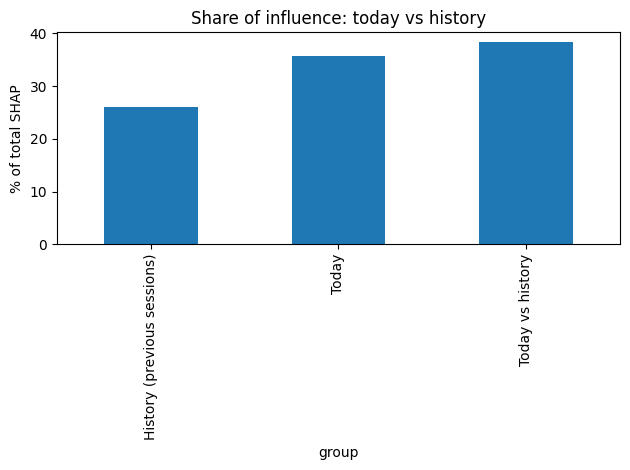

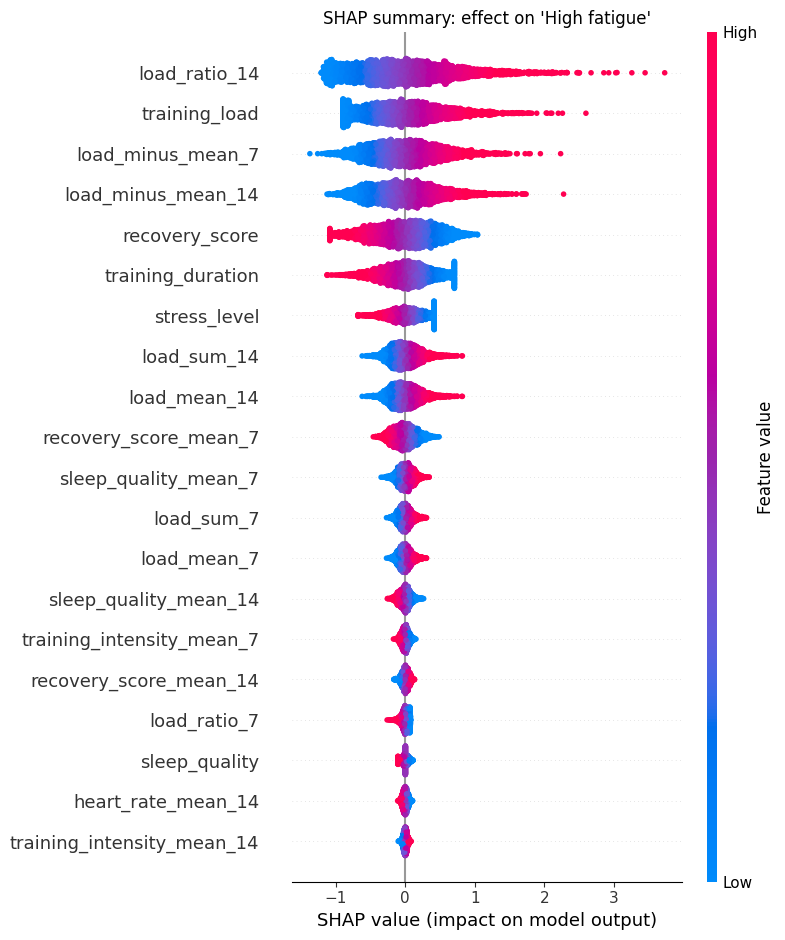


Why session row 0 was predicted 'High' (top 8 factors):
                    shap_value                        group
recovery_score           0.438                        Today
load_minus_mean_7        0.271             Today vs history
load_ratio_14            0.238             Today vs history
training_duration        0.168                        Today
load_minus_mean_14       0.162             Today vs history
load_sum_14             -0.139  History (previous sessions)
load_mean_14            -0.139  History (previous sessions)
load_sum_7              -0.095  History (previous sessions)


In [16]:
!pip install shap -q
import shap
import matplotlib.pyplot as plt

pre = Pipeline(main_pipe.steps[:-1])            # fill missing + scale
lr_model = main_pipe.named_steps["model"]

Xtr_s = pre.transform(X_train)
Xte_s = pre.transform(X_test)

masker = shap.maskers.Independent(Xtr_s, max_samples=len(Xtr_s))
explainer = shap.LinearExplainer(lr_model, masker)
sv = explainer.shap_values(Xte_s)
if isinstance(sv, list):
    sv = np.stack(sv, axis=-1)                   # -> (rows, features, classes)
print("SHAP array shape (rows, features, classes):", sv.shape)

# Importance per feature = average absolute SHAP value
mean_abs = np.abs(sv).mean(axis=0)
imp = pd.DataFrame(mean_abs, index=features,
                   columns=[f"shap_{n}" for n in class_names])
imp["shap_overall"] = imp.mean(axis=1)
imp["group"] = imp.index.map(feature_group)
imp = imp.sort_values("shap_overall", ascending=False)

group_share = imp.groupby("group")["shap_overall"].sum()
group_pct = (100 * group_share / group_share.sum()).round(2)

print("\n=== Top 10 features ===")
print(imp[["group", "shap_overall"]].head(10).round(4))
print("\n=== Share of model influence by group (%) ===")
print(group_pct)

imp.to_csv("/kaggle/working/logreg_shap_feature_importance.csv")
group_pct.rename("percent_of_total_shap").to_csv("/kaggle/working/logreg_shap_group_share.csv")

# Plots
group_pct.plot(kind="bar", title="Share of influence: today vs history")
plt.ylabel("% of total SHAP"); plt.tight_layout()
plt.savefig("/kaggle/working/logreg_shap_group_share.png", dpi=150); plt.show()

shap.summary_plot(sv[:, :, 2], Xte_s, feature_names=features, show=False)
plt.title("SHAP summary: effect on 'High fatigue'")
plt.tight_layout(); plt.savefig("/kaggle/working/logreg_shap_summary_high.png", dpi=150); plt.show()

# Explain ONE prediction
i = 0
pred_cls = int(y_pred[i])
contrib = pd.Series(sv[i, :, pred_cls], index=features)
contrib = contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(8)
print(f"\nWhy session row {i} was predicted '{class_names[pred_cls]}' (top 8 factors):")
print(pd.DataFrame({"shap_value": contrib.round(3), "group": contrib.index.map(feature_group)}))

In [17]:
print(sorted(os.listdir("/kaggle/working")))

['.virtual_documents', 'logistic_regression_metrics.csv', 'logistic_regression_per_class.csv', 'logistic_regression_test_predictions.csv', 'logreg_ablation.csv', 'logreg_counterfactual_example.csv', 'logreg_shap_feature_importance.csv', 'logreg_shap_group_share.csv', 'logreg_shap_group_share.png', 'logreg_shap_summary_high.png', 'logreg_walk_forward.csv']


In [18]:
g = df.groupby("athlete_id")
df["fatigue_prev1"]   = g["fatigue_index"].shift(1)
df["fatigue_mean_7"]  = g["fatigue_index"].transform(
    lambda s: s.shift(1).rolling(7, min_periods=3).mean())

model_df[["fatigue_prev1", "fatigue_mean_7"]] = df.loc[model_df.index, ["fatigue_prev1", "fatigue_mean_7"]]
train_df = model_df[model_df["session_number"] <= 75].copy()
test_df  = model_df[model_df["session_number"] >= 76].copy()

prev_fatigue = ["fatigue_prev1", "fatigue_mean_7"]

sets = {
    "A. Today only": today_feats,
    "E. Today + previous fatigue": today_feats + prev_fatigue,
    "F. Today + history + previous fatigue": today_feats + history_pure + prev_fatigue,
}
rows = []
for name, feats in sets.items():
    _, p, pr, m, t_tr, t_pr = run_logreg(feats, train_df, test_df)
    rows.append({"feature_set": name, "n_features": len(feats),
                 **{k: round(v, 4) for k, v in m.items()}})
out = pd.DataFrame(rows)
out.to_csv("/kaggle/working/logreg_ablation_prev_fatigue.csv", index=False)
print(out[["feature_set", "n_features", "accuracy", "f1_macro", "roc_auc_ovr_macro"]].to_string(index=False))

                          feature_set  n_features  accuracy  f1_macro  roc_auc_ovr_macro
                        A. Today only           7    0.6809    0.6807             0.8533
          E. Today + previous fatigue           9    0.6809    0.6808             0.8543
F. Today + history + previous fatigue          23    0.6804    0.6802             0.8531


In [19]:
row = 0
cls = 2   # High

base = explainer.expected_value[cls]
raw_score = main_pipe.named_steps["model"].decision_function(Xte_s)[row, cls]

print("Baseline + sum of SHAP:", round(base + sv[row, :, cls].sum(), 4))
print("Model raw score:       ", round(raw_score, 4))

Baseline + sum of SHAP: 0.8054
Model raw score:        0.8054


In [20]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

y_pred  = main_pipe.predict(X_test)
y_proba = main_pipe.predict_proba(X_test)

print("Test rows:", len(X_test))
print("Accuracy:  ", round(accuracy_score(y_test, y_pred), 4))
print("F1 (macro):", round(f1_score(y_test, y_pred, average="macro"), 4))
print("ROC-AUC:   ", round(roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro"), 4))

print("\nConfusion matrix (rows = true, columns = predicted):")
print(pd.DataFrame(confusion_matrix(y_test, y_pred),
                   index=[f"true_{n}" for n in class_names],
                   columns=[f"pred_{n}" for n in class_names]))

print("\n", classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

Test rows: 3720
Accuracy:   0.6788
F1 (macro): 0.6785
ROC-AUC:    0.8522

Confusion matrix (rows = true, columns = predicted):
               pred_Low  pred_Moderate  pred_High
true_Low            978            294         32
true_Moderate       315            669        248
true_High            35            271        878

               precision    recall  f1-score   support

         Low       0.74      0.75      0.74      1304
    Moderate       0.54      0.54      0.54      1232
        High       0.76      0.74      0.75      1184

    accuracy                           0.68      3720
   macro avg       0.68      0.68      0.68      3720
weighted avg       0.68      0.68      0.68      3720



In [21]:
i = 0   # any number from 0 to 3719
one_row = X_test.iloc[[i]]

pred = main_pipe.predict(one_row)[0]
proba = main_pipe.predict_proba(one_row)[0]

print("Predicted:", class_names[pred])
print("Actual:   ", class_names[int(y_test.iloc[i])])
print("Probabilities:", {n: round(p, 3) for n, p in zip(class_names, proba)})

Predicted: High
Actual:    Low
Probabilities: {'Low': np.float64(0.06), 'Moderate': np.float64(0.413), 'High': np.float64(0.527)}


In [22]:
import joblib, json

# 1) The trained model
joblib.dump(main_pipe, "/kaggle/working/logistic_regression_model.joblib")

# 2) Settings your app will need
settings = {"q1": float(q1), "q2": float(q2),
            "features": features, "class_names": class_names,
            "first_prediction_session": 15,
            "history_windows": [7, 14]}
json.dump(settings, open("/kaggle/working/model_settings.json", "w"), indent=2)

# 3) Training details (no epochs: the optimizer stops when it converges)
pd.DataFrame([{
    "model": "Logistic Regression",
    "optimizer_iterations_used": int(main_pipe.named_steps["model"].n_iter_.max()),
    "max_iter_allowed": 1000,
    "note": "No epochs. Optimizer stops when it converges."
}]).to_csv("/kaggle/working/logreg_training_info.csv", index=False)

print(sorted(os.listdir("/kaggle/working")))

['.virtual_documents', 'logistic_regression_metrics.csv', 'logistic_regression_model.joblib', 'logistic_regression_per_class.csv', 'logistic_regression_test_predictions.csv', 'logreg_ablation.csv', 'logreg_ablation_prev_fatigue.csv', 'logreg_counterfactual_example.csv', 'logreg_shap_feature_importance.csv', 'logreg_shap_group_share.csv', 'logreg_shap_group_share.png', 'logreg_shap_summary_high.png', 'logreg_training_info.csv', 'logreg_walk_forward.csv', 'model_settings.json']


In [23]:
lr_loaded = joblib.load("/kaggle/working/logistic_regression_model.joblib")
same = (lr_loaded.predict(X_test) == main_pipe.predict(X_test)).all()
print("Reloaded model gives identical predictions:", same)   # should print True

Reloaded model gives identical predictions: True


In [24]:
from sklearn.metrics import f1_score

# Validation split INSIDE the training period (test set stays untouched)
core_df = model_df[model_df["session_number"] <= 60].copy()                       # train
val_df  = model_df[(model_df["session_number"] >= 61) &
                   (model_df["session_number"] <= 75)].copy()                     # validation

def make_logreg_C(C):
    return Pipeline([
        ("fill_missing", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("model", LogisticRegression(C=C, max_iter=1000, random_state=42)),
    ])

rows = []
for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    p = make_logreg_C(C).fit(core_df[features], core_df["fatigue_class"])
    f1 = f1_score(val_df["fatigue_class"], p.predict(val_df[features]), average="macro")
    rows.append({"C": C, "validation_f1_macro": round(f1, 4)})

C_table = pd.DataFrame(rows)
best_C = C_table.sort_values("validation_f1_macro", ascending=False).iloc[0]["C"]
print(C_table.to_string(index=False))
print("\nBest C chosen on validation:", best_C)
C_table.to_csv("/kaggle/working/logreg_C_search_validation.csv", index=False)

      C  validation_f1_macro
  0.001               0.6609
  0.010               0.6691
  0.100               0.6633
  1.000               0.6649
 10.000               0.6663
100.000               0.6667

Best C chosen on validation: 0.01


In [25]:
best_pipe, bp, bpr, best_m, t_tr, t_pr = None, None, None, None, None, None

best_pipe = make_logreg_C(best_C)
t0 = time.perf_counter()
best_pipe.fit(train_df[features], train_df["fatigue_class"])      # sessions 15-75, as before
t_tr = time.perf_counter() - t0

t0 = time.perf_counter()
bp  = best_pipe.predict(test_df[features])
bpr = best_pipe.predict_proba(test_df[features])
t_pr = time.perf_counter() - t0

best_m = score(test_df["fatigue_class"], bp, bpr)

out = pd.DataFrame([{"model": f"Logistic Regression (best C={best_C})",
                     "train_wall_time_sec": round(t_tr, 4),
                     "predict_wall_time_sec": round(t_pr, 4),
                     **{k: round(v, 4) for k, v in best_m.items()}}])
out.to_csv("/kaggle/working/logreg_best_C_metrics.csv", index=False)
print(out.T)

joblib.dump(best_pipe, "/kaggle/working/logistic_regression_best_C_model.joblib")

                                                       0
model                  Logistic Regression (best C=0.01)
train_wall_time_sec                               0.0913
predict_wall_time_sec                             0.0101
accuracy                                          0.6793
balanced_accuracy                                 0.6787
precision_macro                                   0.6782
recall_macro                                      0.6787
f1_macro                                          0.6784
f1_weighted                                       0.6787
roc_auc_ovr_macro                                 0.8516


['/kaggle/working/logistic_regression_best_C_model.joblib']